In [1]:
# System
import sys

sys.path.append("../..")

In [2]:
# Setup
from importlib import import_module
from pathlib import Path
from shutil import rmtree

import numpy as np
from src.utils import plot_correlation, plot_distribution, print, tex_to_str

In [3]:
# Parameters
# Dataset
dataset = "mock2"  # *
n_samples = 200000
seed = 42

# Figure
features = [r"$x_1$", r"$x_5$", r"$x_6$"]  # *
bins = np.linspace(-10, 10, 101)

# Directory
FIGURES_DIR = Path("figures")

if FIGURES_DIR.exists():
    rmtree(FIGURES_DIR)
FIGURES_DIR.mkdir()

In [4]:
# Dataset
module = import_module(f"src.datasets.{dataset}")
load_data = getattr(module, "load_data")
(x_train, y_train), (x_test, y_test) = load_data(n_samples, seed)

print(f"{x_train.shape=}")
print(f"{y_train.shape=}")
print(f"{x_test.shape=}")
print(f"{y_test.shape=}")

x_train.shape=(100000, 3)
y_train.shape=(100000, 1)
x_test.shape=(100000, 3)
y_test.shape=(100000, 1)


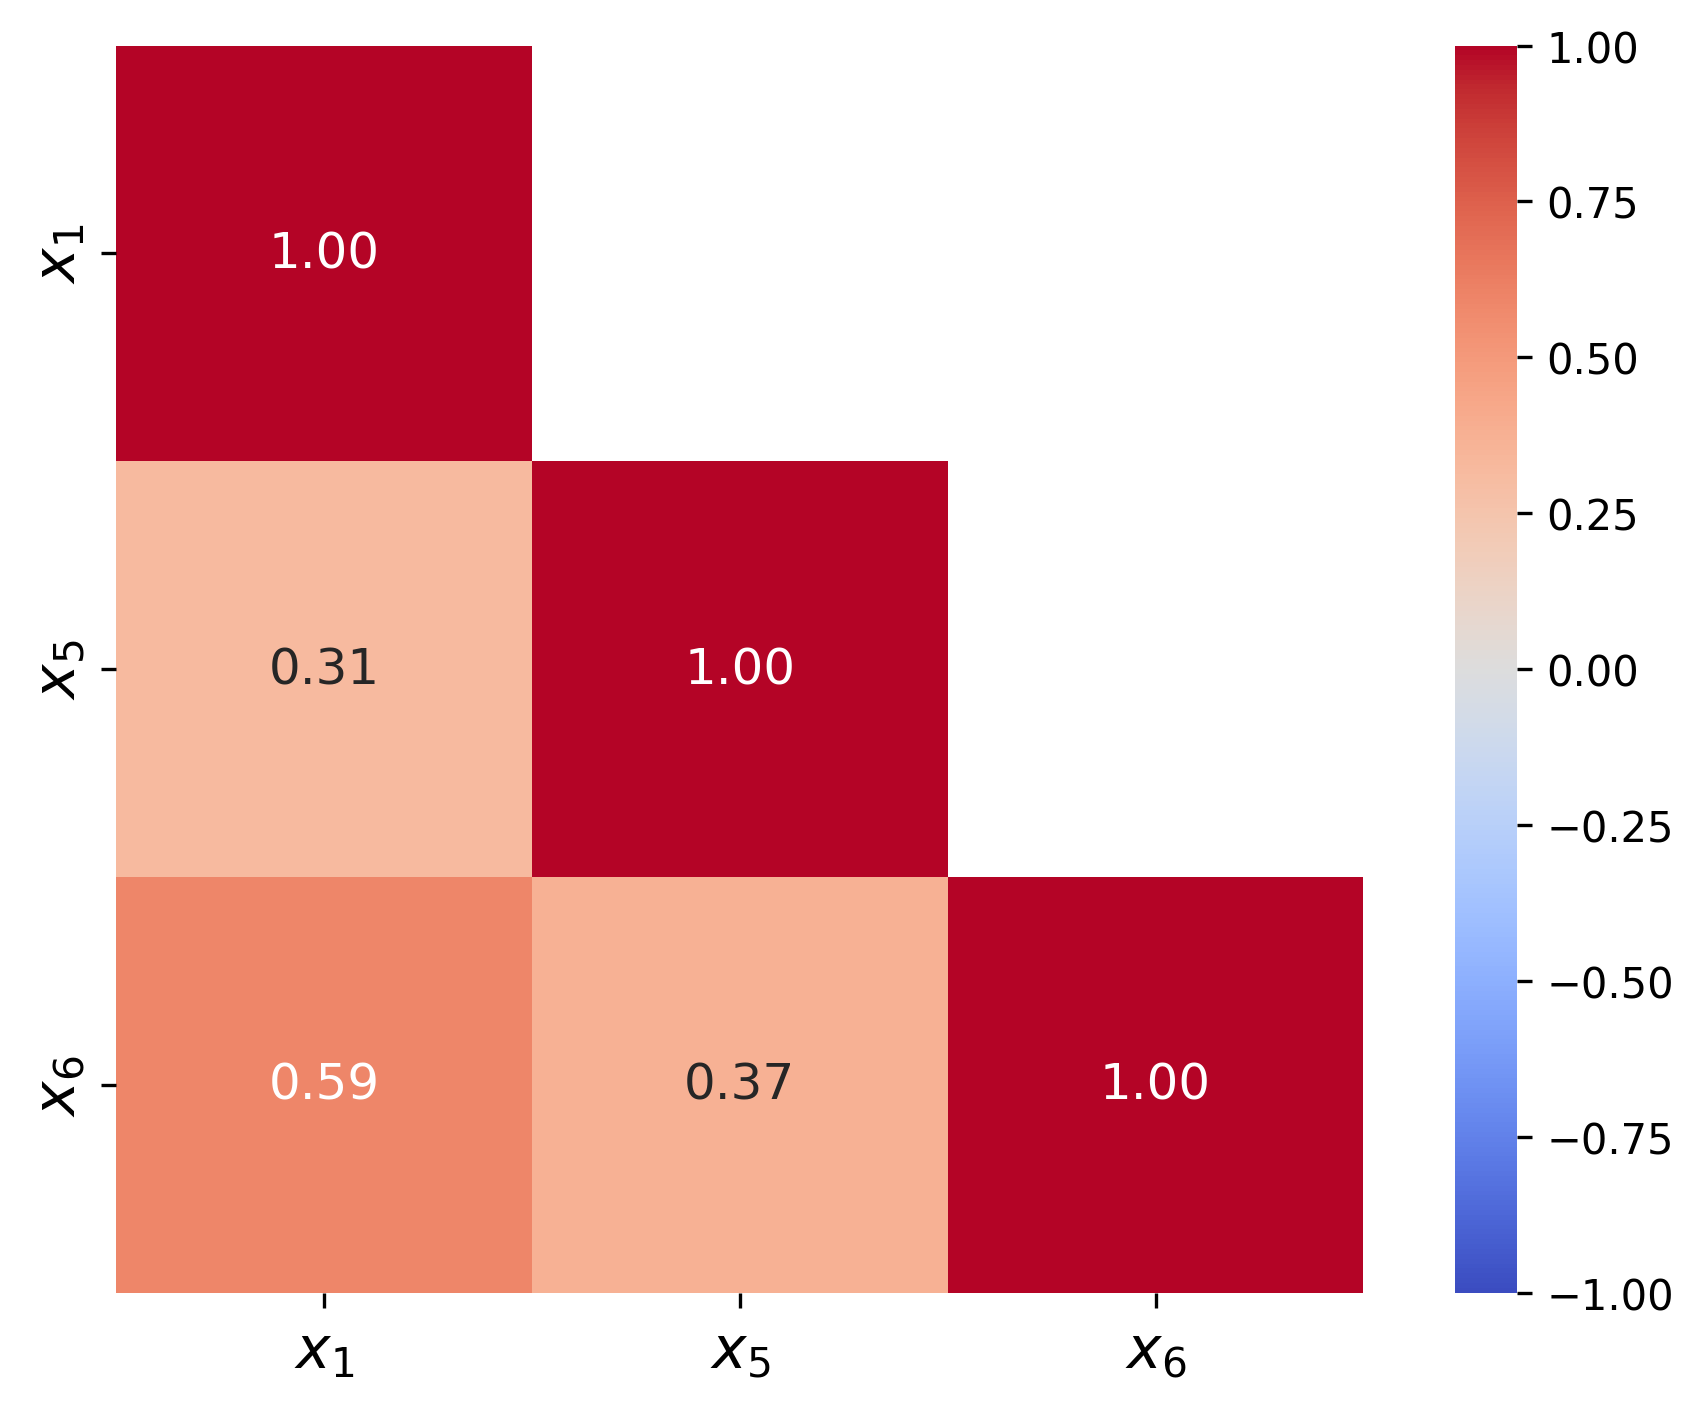

In [5]:
# Figure: correlation
plot_correlation(x_train, features)
plot_correlation(x_train, features, to_file=FIGURES_DIR / "correlation.pdf")

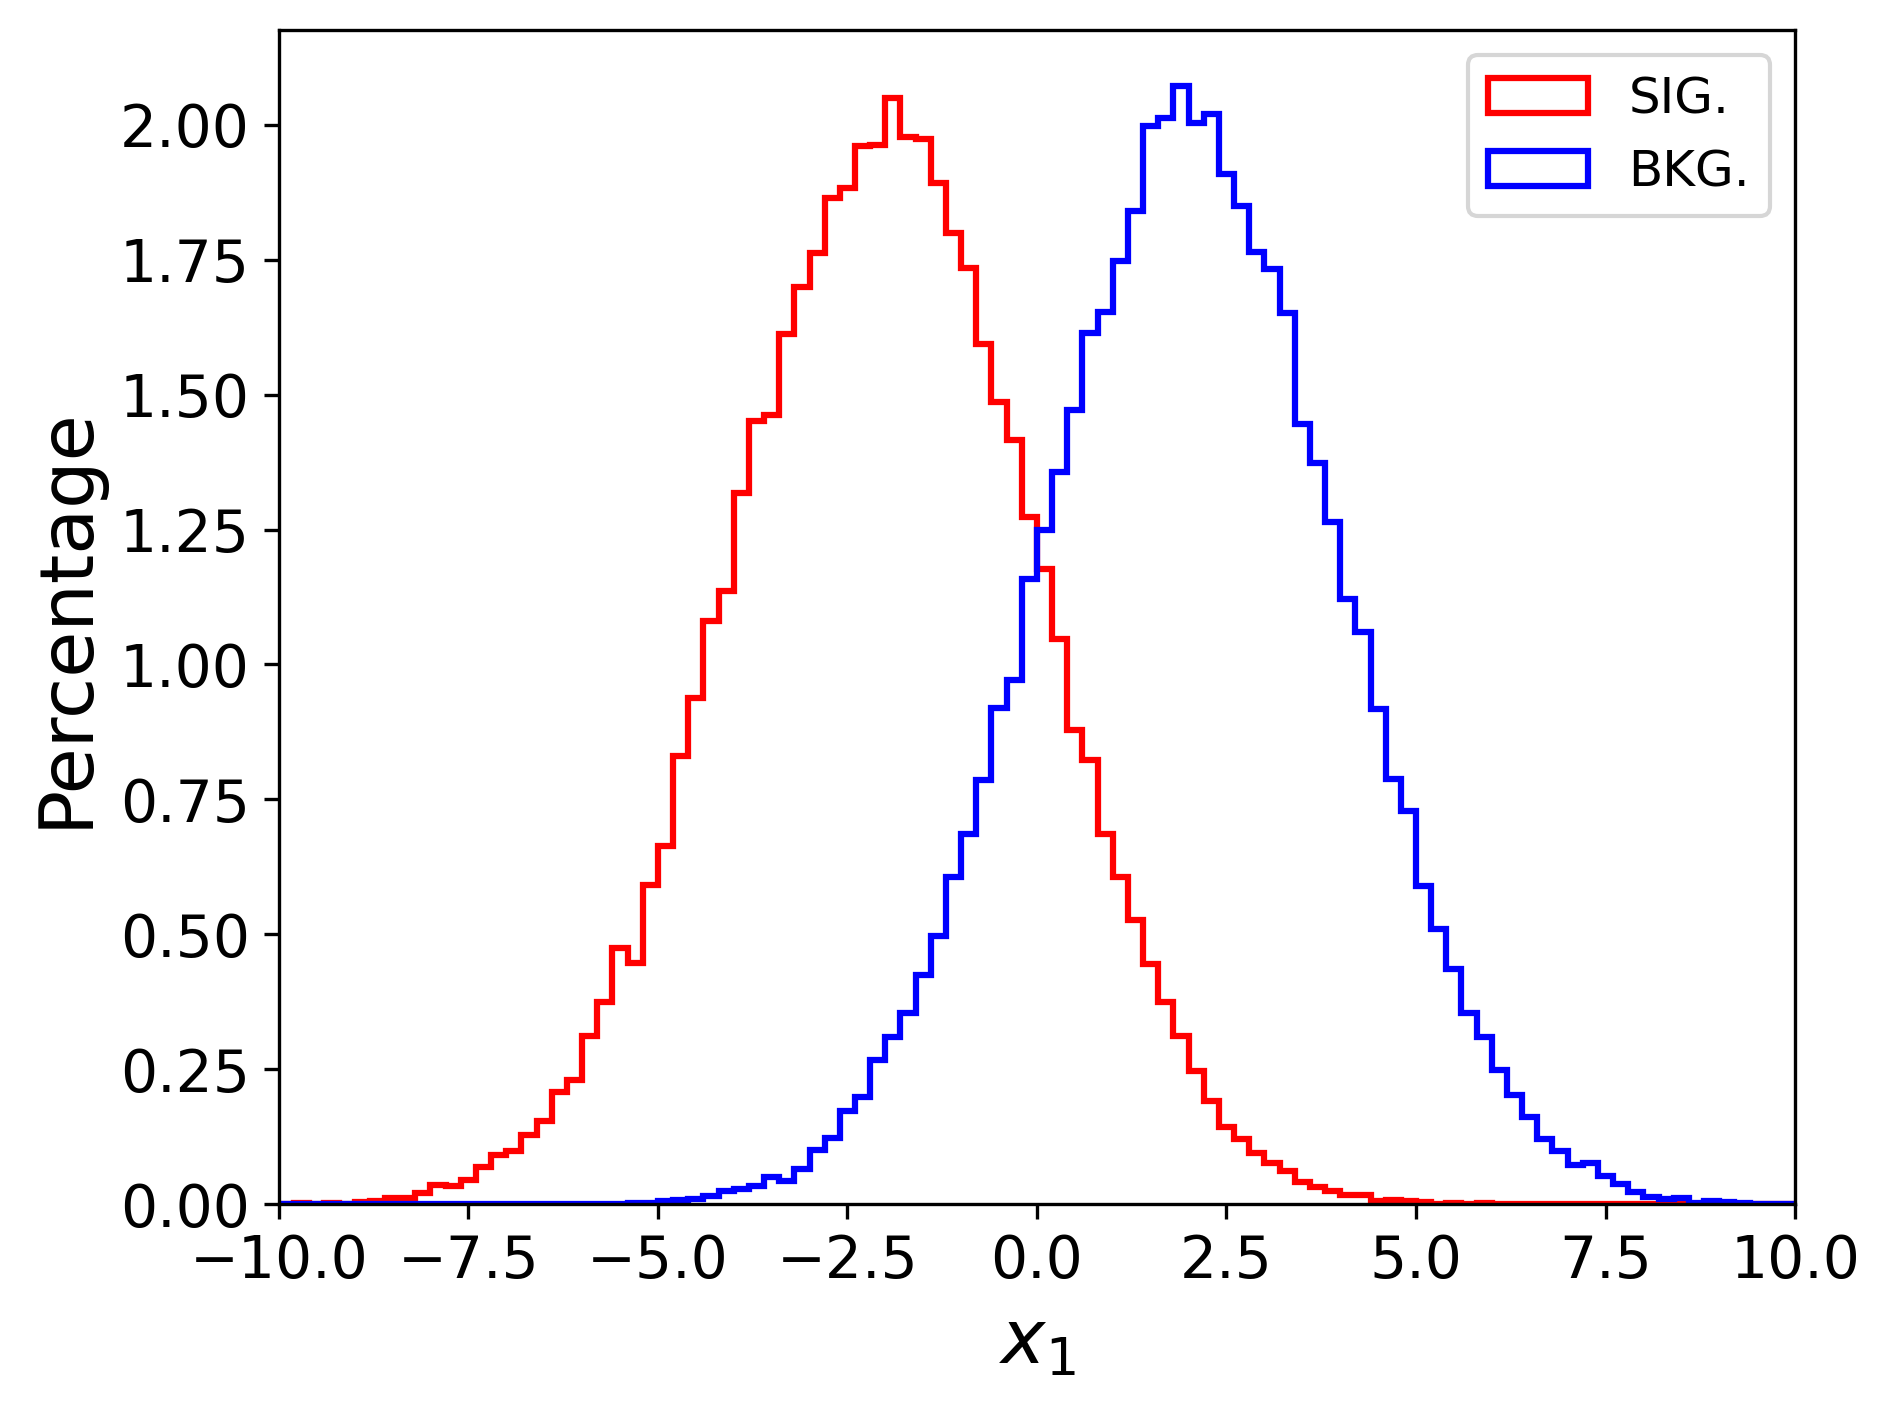

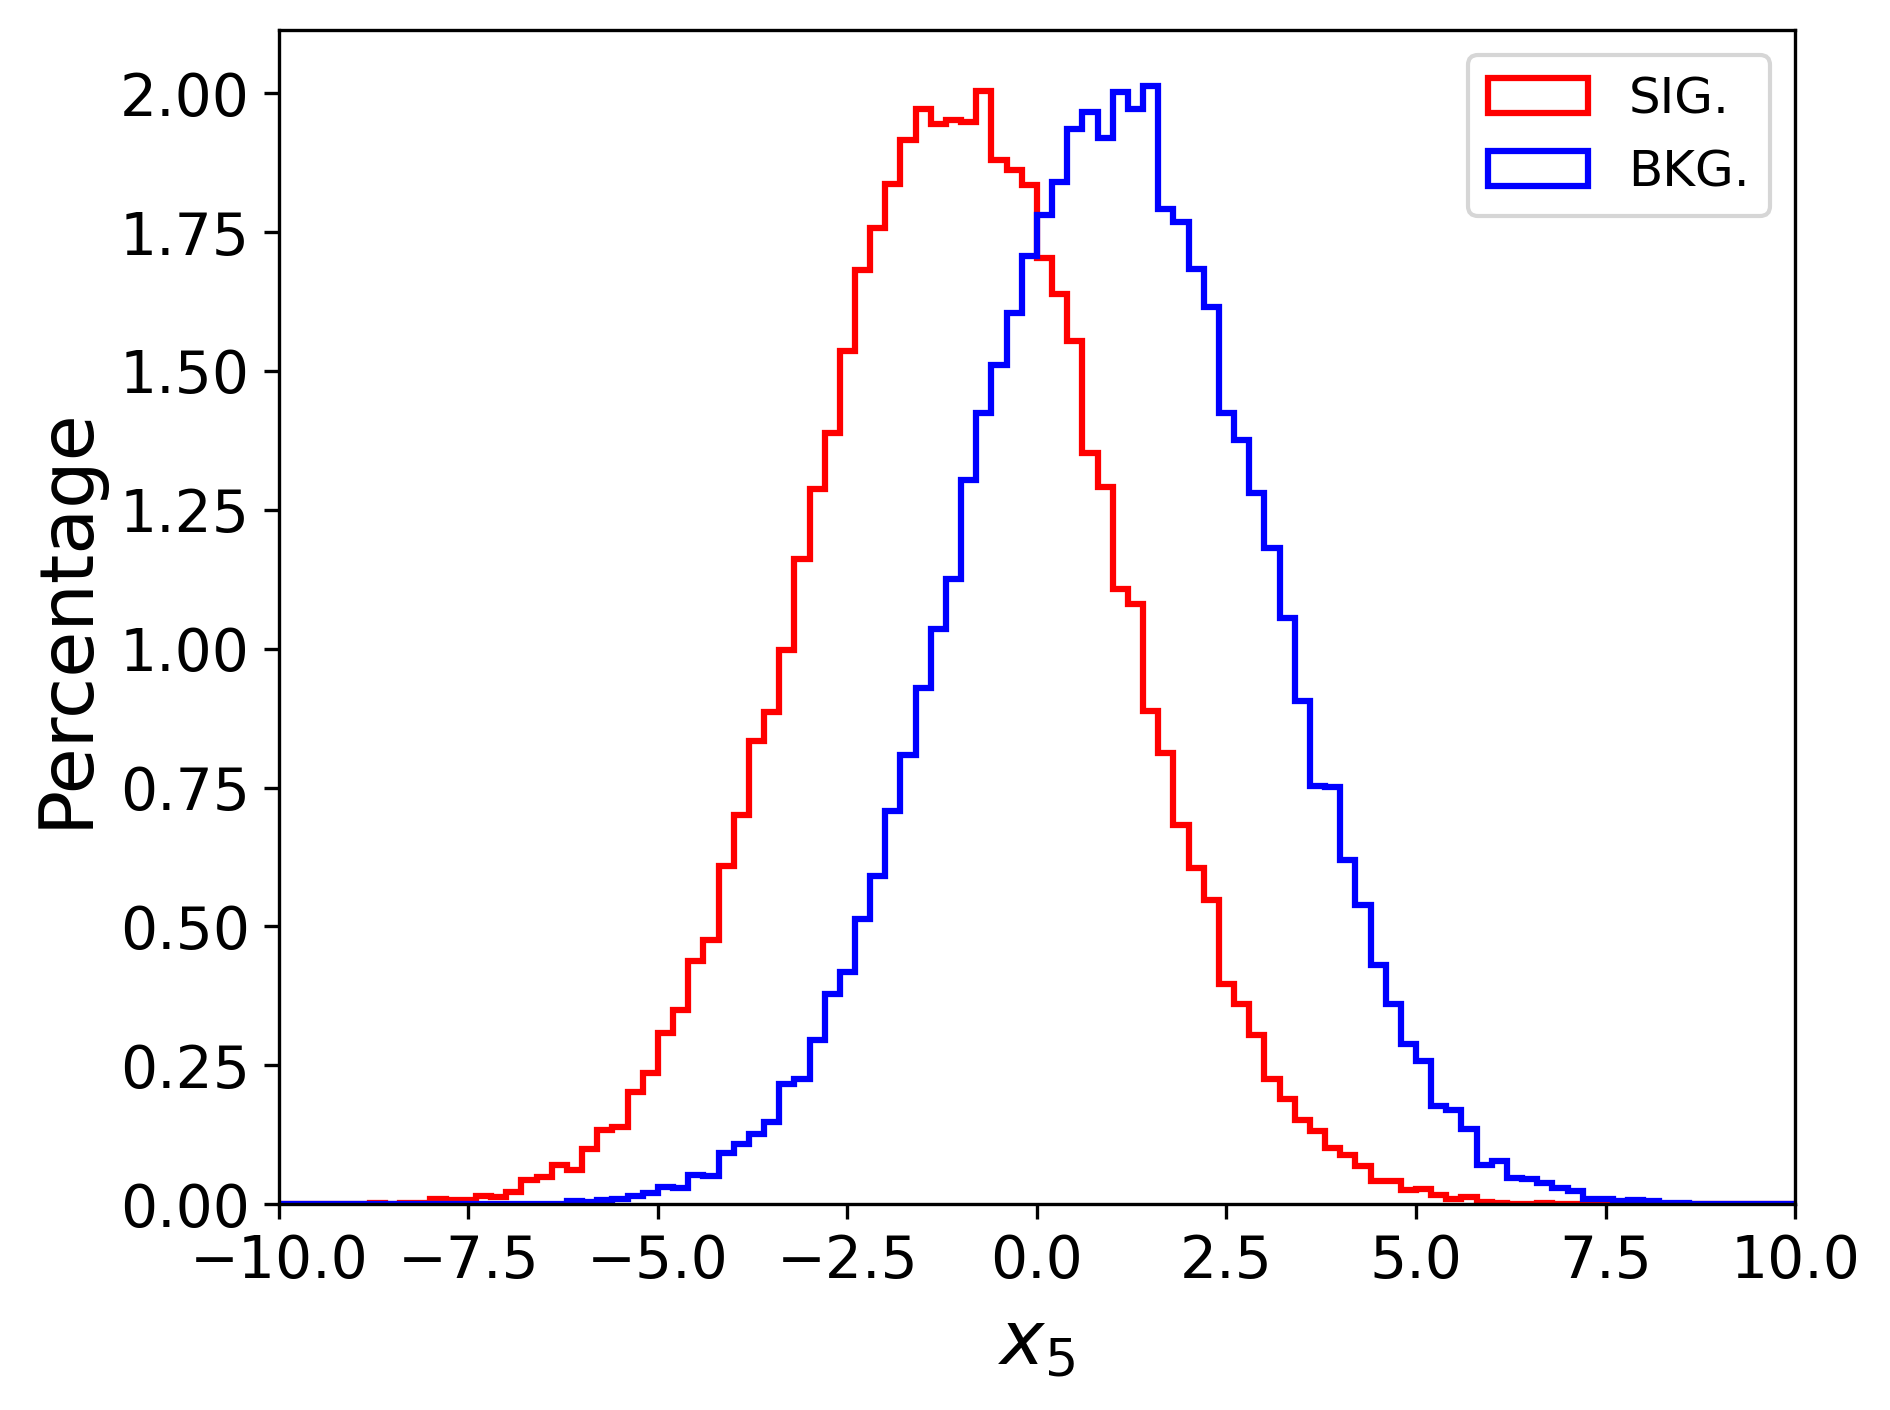

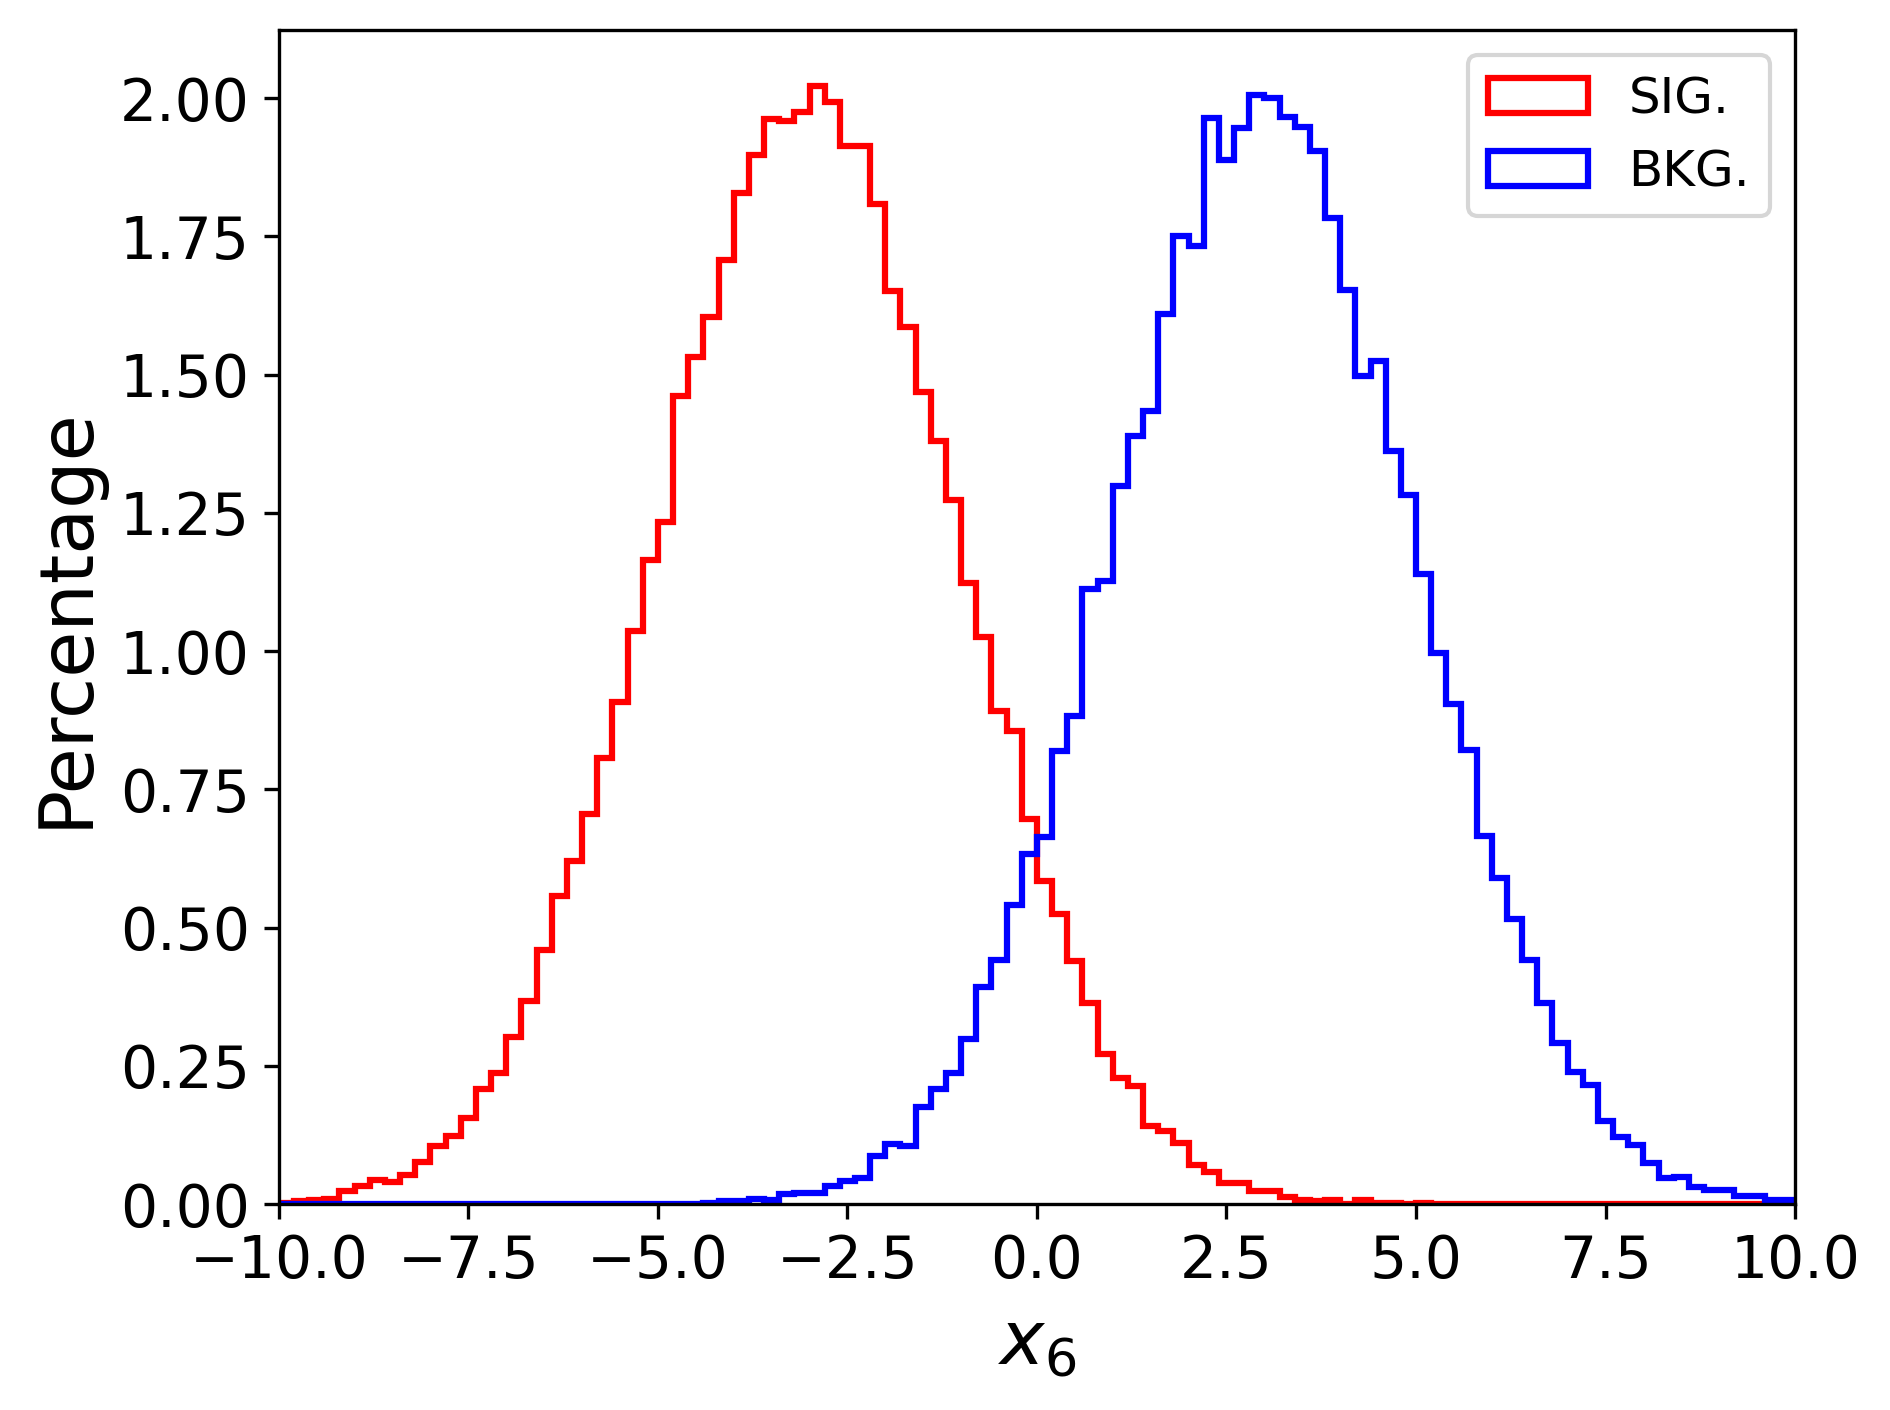

In [6]:
# Figure: distribution
for i, feature in enumerate(features):
    sig = x_train[y_train.squeeze() == 1, i]
    bkg = x_train[y_train.squeeze() == 0, i]
    weights_sig = 100 * np.ones_like(sig) / len(x_train[:, i])
    weights_bkg = 100 * np.ones_like(bkg) / len(x_train[:, i])

    plot_distribution(
        data=[sig, bkg],
        bins=bins,
        colors=["red", "blue"],
        labels=["SIG.", "BKG."],
        weights=[weights_sig, weights_bkg],
        xlabel=feature,
        ylabel="Percentage",
    )

    plot_distribution(
        data=[sig, bkg],
        bins=bins,
        colors=["red", "blue"],
        labels=["SIG.", "BKG."],
        weights=[weights_sig, weights_bkg],
        xlabel=feature,
        ylabel="Percentage",
        to_file=FIGURES_DIR / f"{tex_to_str(feature)}.pdf",
    )